In [165]:
### Will use AtlasOpenMagic package to download data and MC files and reconstruct Higgs peak
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v
from matplotlib.ticker import AutoMinorLocator # for minor ticks

In [3]:
#atom.available_releases()
atom.set_release("2025e-13tev-beta")
skim = '4lep'

#the data keys I copied from the tutorial
#TODO: separate out the backgrounds and figure out how to set the dids by self
data_keys = {
    r'Data':{'dids':['data']},
    r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':{'dids': [410470,410155,410218,
                                                        410219,412043,364243,
                                                        364242,364246,364248,
                                                        700320,700321,700322,
                                                        700323,700324,700325], 'color': "#6b59d3" }, # purple
    r'Background $ZZ^{*}$':     {'dids': [700600],'color': "#ff0000" },# red
    r'Signal ($m_H$ = 125 GeV)':  {'dids': [345060, 346228, 346310, 346311, 346312,
                                          346340, 346341, 346342],'color': "#00cdff" },# light blue
}

allsamples = atom.build_dataset(data_keys, skim = skim,protocol = 'https', cache = True)

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 552.04datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [22]:
# write functions for making cuts
variables = ['num_events','lep_pt','lep_eta','lep_phi','lep_e','lep_n','lep_charge','lep_type',
             'trigE','trigM','lep_isTrigMatched','lep_isLooseID','lep_isMediumID','lep_isLooseIso']

# cut on num leptons
# if true, keep event
def cut_lep_n(lep_n):
    cutboolarray = (lep_n == 4)
    return cutboolarray

# check if the event was triggered on either mass or energy
# if the event passes cut, return true
def cut_trigger(trigE,trigM):
    cutboolarray = trigE | trigM
    return (cutboolarray)

# trigmatch is awk array, each entry corresponds to an event
# each entry is a list of booleans for each lepton and whether it was triggered on
# ensure that at least one of the leptons in the event was triggered on
# returns a bool array, true if the event passes cut
# the ak.sum(axis=1) means we sum the boolean values in each event (sum columns/lepton bool values of each event row)
def cut_trigger_match(trigmatch):
    cutboolarray = (ak.sum(trigmatch,axis=1) >= 1) #1 is True, 0 is False
    return cutboolarray

# now check to make sure that every lepton in the event is isolated + identified
# if electron, check identified as electron and isolated, same with muon
# note that lep num cut must already be applied
def cut_ID_iso(pid,id_e,iso_e,id_mu,iso_mu):
    #if all 4 leptons are electron, identified, isolated, return True
    # also return True if we have 2mu, 2e
    # do this by 
    cut_earray = ak.sum((id_e & (pid == 11) & iso_e),axis=1) 
    cut_muarray = ak.sum((id_mu & (pid == 13) & iso_mu),axis=1)

    boolarray_4e_or4mu = (cut_earray | cut_muarray) == 4
    boolarray_2e       = (cut_earray == 2) 
    boolarray_2mu      = (cut_muarray ==2)

    # if event passes either muon or electron cut, return True
    return (boolarray_4e_or4mu | (boolarray_2e & boolarray_2mu))

# cut on pT
# these cuts can later be varied
# requirements: 1st particle pt > 20gev, 2nd > 15Gev, 3rd > 10GeV
def cut_pt(lep_pt):
    pt1 = lep_pt[:,0]
    pt2 = lep_pt[:,1]
    pt3 = lep_pt[:,2]
    pt1cut = pt1 > 20 # GeV
    pt2cut = pt2 > 15 
    pt3cut = pt3 > 10
    return (pt1cut & pt2cut & pt3cut)

# now cut on lep charge
# H->4l process must produce two pairs of oppositely charged leps, total charge = 0
# if true, event passes
def cut_lep_charge(lep_charge):
    cutboolarray = (ak.sum(lep_charge,axis = 1) == 0)
    return cutboolarray

# ensure that the event returned either 4mu, 4e, or 2mu+2e
#TODO upgrade the cut to ensure that the pair actually came from a Z decay
def cut_lep_type(lep_type):
    #each entry of lep_type is an array of the pids of the leptons inside
    pidsum = ak.sum(lep_type,axis=1)
    is4e = pidsum == 11*4
    is4mu = pidsum == 13*4
    is2e2mu = pidsum == 11*2+13*2
    cutboolarray = is4e | is4mu | is2e2mu
    return cutboolarray

def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"E":E})
    p4_sum = p4[:,0] + p4[:,1] + p4[:,2] + p4[:,3]
    M = p4_sum.M
    return M

In [23]:
# now examine one data file to ensure cuts are working properly
print("First data sample: " + str(allsamples['Data']['list'][0]))
# open the file, the tree is named analysis
file1 = uproot.open(allsamples['Data']['list'][0])
tree1 = file1['analysis']

# loop over iterated tree, check to see what the distribution of lep num is
lepnumarray =[]

for data in tree1.iterate(variables,library='ak'):
    for lepnum in data['lep_n']:
    # use to make a quick histo of the lepnum
        lepnumarray.append(lepnum)

    # do cuts on the data file
    print("Num events before cuts: "+str(len(data)))

    # the cuts are vectorized for effiency
    # each cut passes a bool array back to the data ak array
    # for all events with False in the bool array, the event is tossed

    data = data[cut_lep_n(data['lep_n'])]
    print("Num events after lep_n cuts: "+str(len(data)))

    data = data[cut_trigger(data['trigE'],data['trigM'])]
    data = data[cut_trigger_match(data['lep_isTrigMatched'])]
    print("Num events after trigger cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftrigcut = ak.sum(data['lep_type'],axis=1) 

    data = data[cut_pt(data['lep_pt'])]
    print("Num events after pt cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_afptcut = ak.sum(data['lep_type'],axis=1) 

    # electron should have loose ID, ID comes from ecal
    # muon should have medium ID (atlas recommendation?)
    # both should have loose iso criteria
    # inputs are pid,id_e,iso_e,id_mu,iso_mu
    data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                data['lep_isLooseIso'],data['lep_isMediumID'],
                data['lep_isLooseIso'])]
    print("Num events after ID iso cuts: "+str(len(data)))

    data = data[cut_lep_charge(data['lep_charge'])]
    print("Num events after lep charge cuts: "+str(len(data)))
    
    data = data[cut_lep_type(data['lep_type'])]
    print("Num events after lep type cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftypecut = ak.sum(data['lep_type'],axis=1) 

    #calculate mass
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    print(data['mass'])


First data sample: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
[472, 264]


In [131]:
#hist agrees with results of cut_lep_n
#plt.hist(lepnumarray,bins=np.arange(4,10,1))
#plt.xlim(4,8)

In [130]:
# hist agrees with 
#print(pidsum_b4typecut)
#plt.hist(pidsum_aftrigcut,bins=np.arange(0,100,1),color='red',label='after trig cuts')
#plt.hist(pidsum_afptcut,bins=np.arange(40,60,1),color='blue',label='after pt cuts')
#plt.hist(pidsum_aftypecut,bins=np.arange(0,100,1),color='green',label='after type cuts')
#plt.xlim(44,60)
#plt.legend()

In [ ]:
# now work on handling MC files
# first need a function for calculating the weights
# the total weight is given by lumi * cross section * (many other variables) / sum of weights
weight_vars = ["filteff", "kfac", "xsec", "mcWeight","ScaleFactor_PILEUP",
                "ScaleFactor_ELE","ScaleFactor_MUON","ScaleFactor_LepTRIGGER"]
# don't want to multiply sum of weights in weight calc, but want it for tree iteration
allweight_vars = weight_vars + ['sum_of_weights']
allvars = variables + allweight_vars

def calc_weight(weightvardict,weight_variables,tot_weight,lumi):
    # xsec given in pb, so multiply by 1000 to get in fb
    weight = lumi * 1000 / tot_weight #returns an array of length n_events 
    for var in weight_variables:
        # we need to extract the array of the values of the variable for each variable
        # but they're packaged inside the dictionary, use this to pull out
        varfloatarray = abs(weightvardict[var]) # use abs to protect against negative weights.
        weight = weight * varfloatarray 
    return weight #array len n_events

In [60]:
# download one MC file and test the weight calculations
for s in allsamples: print(s)
print(allsamples['Signal ($m_H$ = 125 GeV)']['list'])
f_mctest = uproot.open(allsamples['Signal ($m_H$ = 125 GeV)']['list'][0])

Data
Background $Z,t\bar{t},t\bar{t}+V,VVV$
Background $ZZ^{*}$
Signal ($m_H$ = 125 GeV)
['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_345060.PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_ZZ4l.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346228.PowhegPy8EG_NNPDF30_AZNLOCTEQ6L1_VBFH125_ZZ4lep_notau.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346310.PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Zincl_H_incl_MINLO.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346311.PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Wincl_H_incl_MINLO.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346312.PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Wincl_H_incl_MINLO.4lep.root', 'simplecache::https://opendata.cern.ch/eos/open

In [92]:
t_mctest = f_mctest['analysis']
mass_mctest = []
weights_mctest = []
# for the MC file analysis, need to use variables for cuts + variables for 
for data in t_mctest.iterate(allvars,library='ak'):
    print("Num events before cuts: "+str(len(data)))

    # do all cuts and mass calculations
    data = data[cut_lep_n(data['lep_n'])]
    print("Num events after lep_n cuts: "+str(len(data)))

    data = data[cut_trigger(data['trigE'],data['trigM'])]
    data = data[cut_trigger_match(data['lep_isTrigMatched'])]
    print("Num events after trigger cuts: "+str(len(data)))

    data = data[cut_pt(data['lep_pt'])]
    print("Num events after pt cuts: "+str(len(data)))

    # electron should have loose ID, ID comes from ecal
    # muon should have medium ID (atlas recommendation?)
    # both should have loose iso criteria
    # inputs are pid,id_e,iso_e,id_mu,iso_mu
    data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                data['lep_isLooseIso'],data['lep_isMediumID'],
                data['lep_isLooseIso'])]
    print("Num events after ID iso cuts: "+str(len(data)))

    data = data[cut_lep_charge(data['lep_charge'])]
    print("Num events after lep charge cuts: "+str(len(data)))
    
    data = data[cut_lep_type(data['lep_type'])]
    print("Num events after lep type cuts: "+str(len(data)))

    nOut = len(data)

    #calculate mass
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    mass_mctest.append(data['mass'])

    # now do weight calculations
    lumi_madeup = 1.0 # i don't know the luminosity of this one sample but this is just a test
    data['totalWeight'] = calc_weight(data[weight_vars],weight_vars,data['sum_of_weights'],lumi_madeup)
    weights_mctest.append(data['totalWeight'])

weights_mctest_arr = ak.concatenate(weights_mctest)
mass_mctest_arr = ak.concatenate(mass_mctest)

print(mass_mctest_arr)
print(weights_mctest_arr)

Num events before cuts: 313213
Num events after lep_n cuts: 309559
Num events after trigger cuts: 277862
Num events after pt cuts: 161319
Num events after ID iso cuts: 132573
Num events after lep charge cuts: 131214
Num events after lep type cuts: 131214
Num events before cuts: 111667
Num events after lep_n cuts: 110384
Num events after trigger cuts: 99012
Num events after pt cuts: 57664
Num events after ID iso cuts: 47336
Num events after lep charge cuts: 46853
Num events after lep type cuts: 46853
[124, 128, 124, 121, 122, 126, 122, 124, ..., 127, 122, 115, 124, 114, 128, 126]
[3.82e-06, 3.86e-06, 3.99e-06, 3.83e-06, ..., 3.69e-06, 3.59e-06, 3.58e-06]


Text(0.5, 1.0, 'Mass distribution for MC Higgs $m_H = 125$ GeV sample')

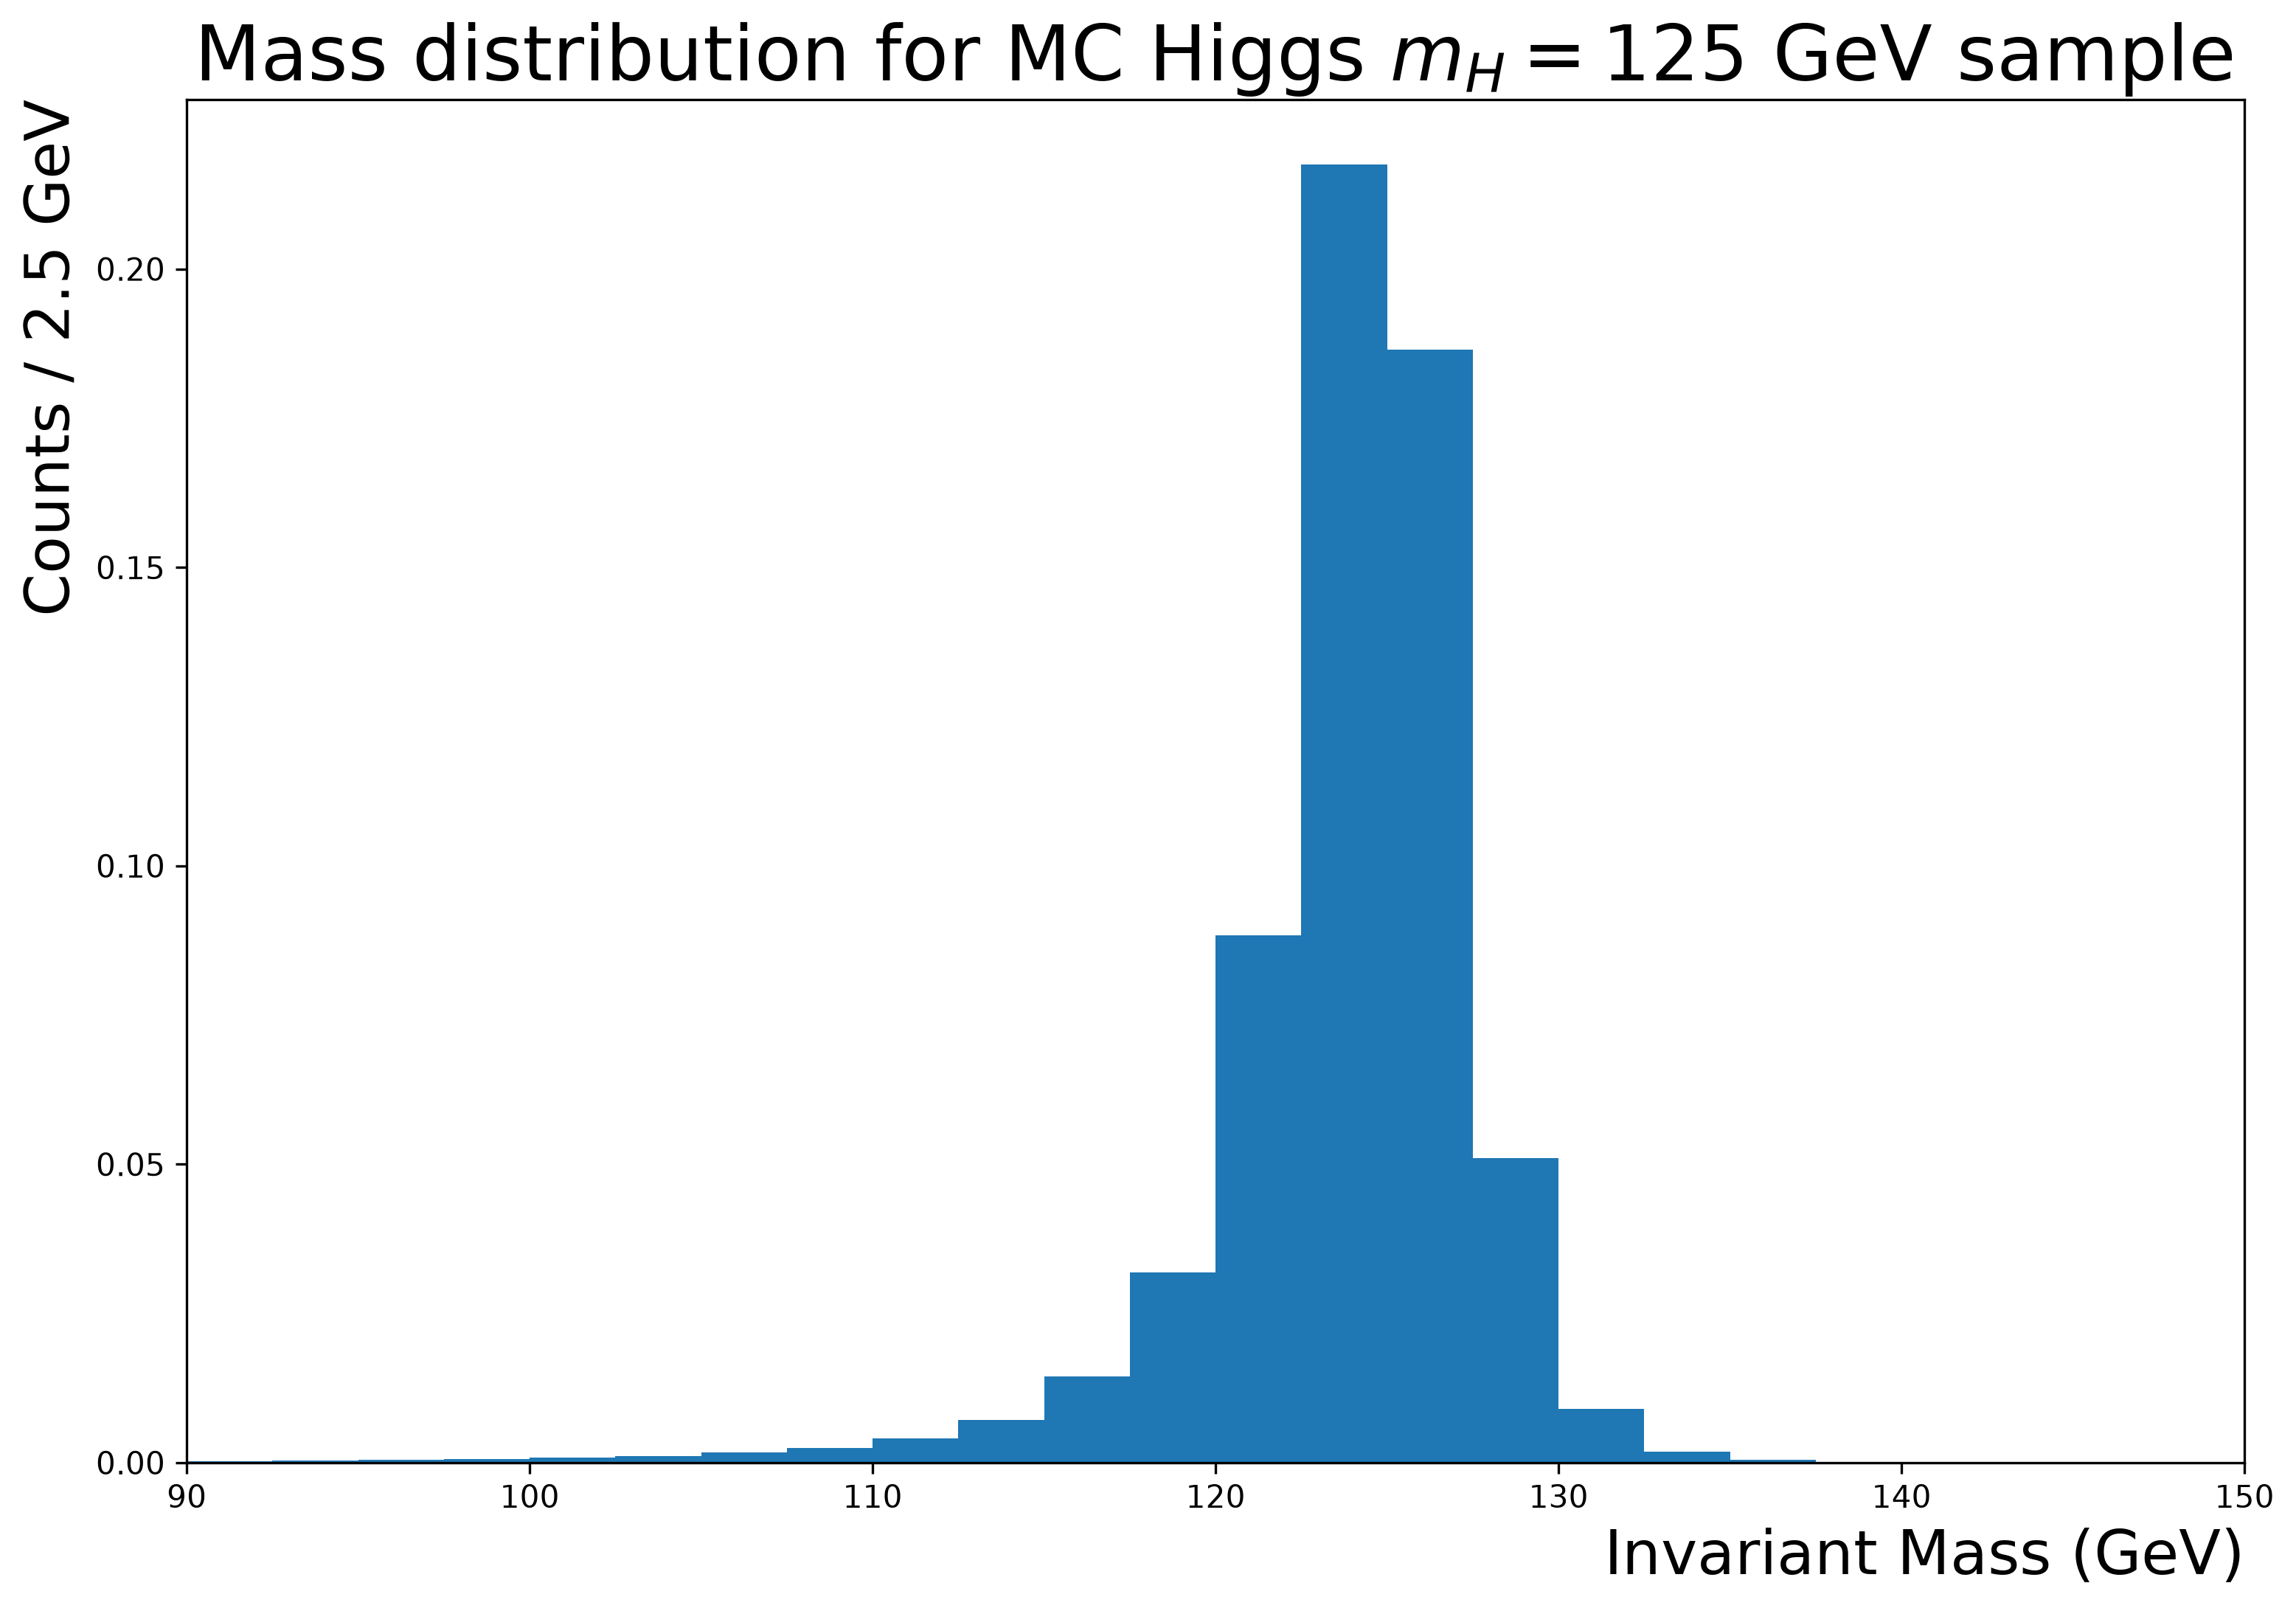

In [93]:
# now plot this MC signal process

# copied below
#TODO - remove repeat
xmin = 80 # GeV for all 
xmax = 250
stepsize = 2.5 
binlist = np.arange(xmin,xmax+stepsize,stepsize)
bincenters = np.arange(xmin+stepsize/2,xmax+stepsize/2,stepsize)

# convert from ak to np array for plotting
mctest_masses = ak.to_numpy(mass_mctest_arr)
mctest_weights = ak.to_numpy(weights_mctest_arr)

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
ax.hist(mctest_masses,bins=binlist,weights=mctest_weights)
ax.set_xlim(90,150)
ax.set_xlabel("Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title("Mass distribution for MC Higgs $m_H = 125$ GeV sample",fontsize=25)


In [97]:
# loop through all files
lumi = 36.6 #fb-1, total luminosity of the release
allinfo = {} # empty dictionary for ak arrays, info includes data and MC

# loop over Data, MC signal, MC backgrounds
for s in allsamples:
    print("\n\n Processing sample: " + str(s))
    #check to see if it's a data or MC sample to see whether need to do mass cuts
    if s != 'Data': mcbool = True
    else: mcbool = False

    thissample_info = []
    # loop over all files in this sample
    for i,f in enumerate(allsamples[s]['list']):
        #if i>5:
        #    break
        thisfile_info = []
        starttime = time.time() # start timer
        print(r'\t Processing file: ' + str(f))

        # open the file, the tree is named analysis
        file = uproot.open(f)
        tree = file['analysis']
        # loop through tree
        for data in tree.iterate(allvars,library='ak'):
            nIn = len(data)
            # do cuts on the data file
            print("Num events before cuts: "+str(len(data)))

            # the cuts are vectorized for effiency
            # each cut passes a bool array back to the data ak array
            # for all events with False in the bool array, the event is tossed

            data = data[cut_lep_n(data['lep_n'])]
            print("Num events after lep_n cuts: "+str(len(data)))

            data = data[cut_trigger(data['trigE'],data['trigM'])]
            data = data[cut_trigger_match(data['lep_isTrigMatched'])]
            print("Num events after trigger cuts: "+str(len(data)))

            data = data[cut_pt(data['lep_pt'])]
            print("Num events after pt cuts: "+str(len(data)))

            # electron should have loose ID, ID comes from ecal
            # muon should have medium ID (atlas recommendation?)
            # both should have loose iso criteria
            # inputs are pid,id_e,iso_e,id_mu,iso_mu
            data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                        data['lep_isLooseIso'],data['lep_isMediumID'],
                        data['lep_isLooseIso'])]
            print("Num events after ID iso cuts: "+str(len(data)))

            data = data[cut_lep_charge(data['lep_charge'])]
            print("Num events after lep charge cuts: "+str(len(data)))
            
            data = data[cut_lep_type(data['lep_type'])]
            print("Num events after lep type cuts: "+str(len(data)))

            #calculate mass
            data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
            #print(data['mass'])

            #now do weight calculations if sample is MC
            if mcbool == True:
                data['totalWeight'] = calc_weight(data[weight_vars],weight_vars,data['sum_of_weights'],lumi)
                # if MC, nOut should be sum of weights
                nOut = sum(data['totalWeight'])
            else:
                nOut = len(data)
            
            thisfile_info.append(data)

        thissample_info.append(ak.concatenate(thisfile_info))
        endtime = time.time()
        duration = endtime - starttime
        print(f"\t nIn:{nIn}\tnOut:{nOut}\tin {round(duration,1)} s.")

    allinfo[s] = ak.concatenate(thissample_info)



 Processing sample: Data
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
	 nIn:3708	nOut:2	in 0.2 s.
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root
Num events before cuts: 27501
Num events after lep_n cuts: 25092
Num events after trigger cuts: 3420
Num events after pt cuts: 765
Num events after ID iso cuts: 19
Num events after lep charge cuts: 17
Num events after lep type cuts: 17
	 nIn:27501	nOut:17	in 0.9 s.
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root
Num events before cuts: 17783
Num e

Num of data events that pass cut: 1279
68 68


Text(0.5, 1.0, 'Mass distribution for all data samples')

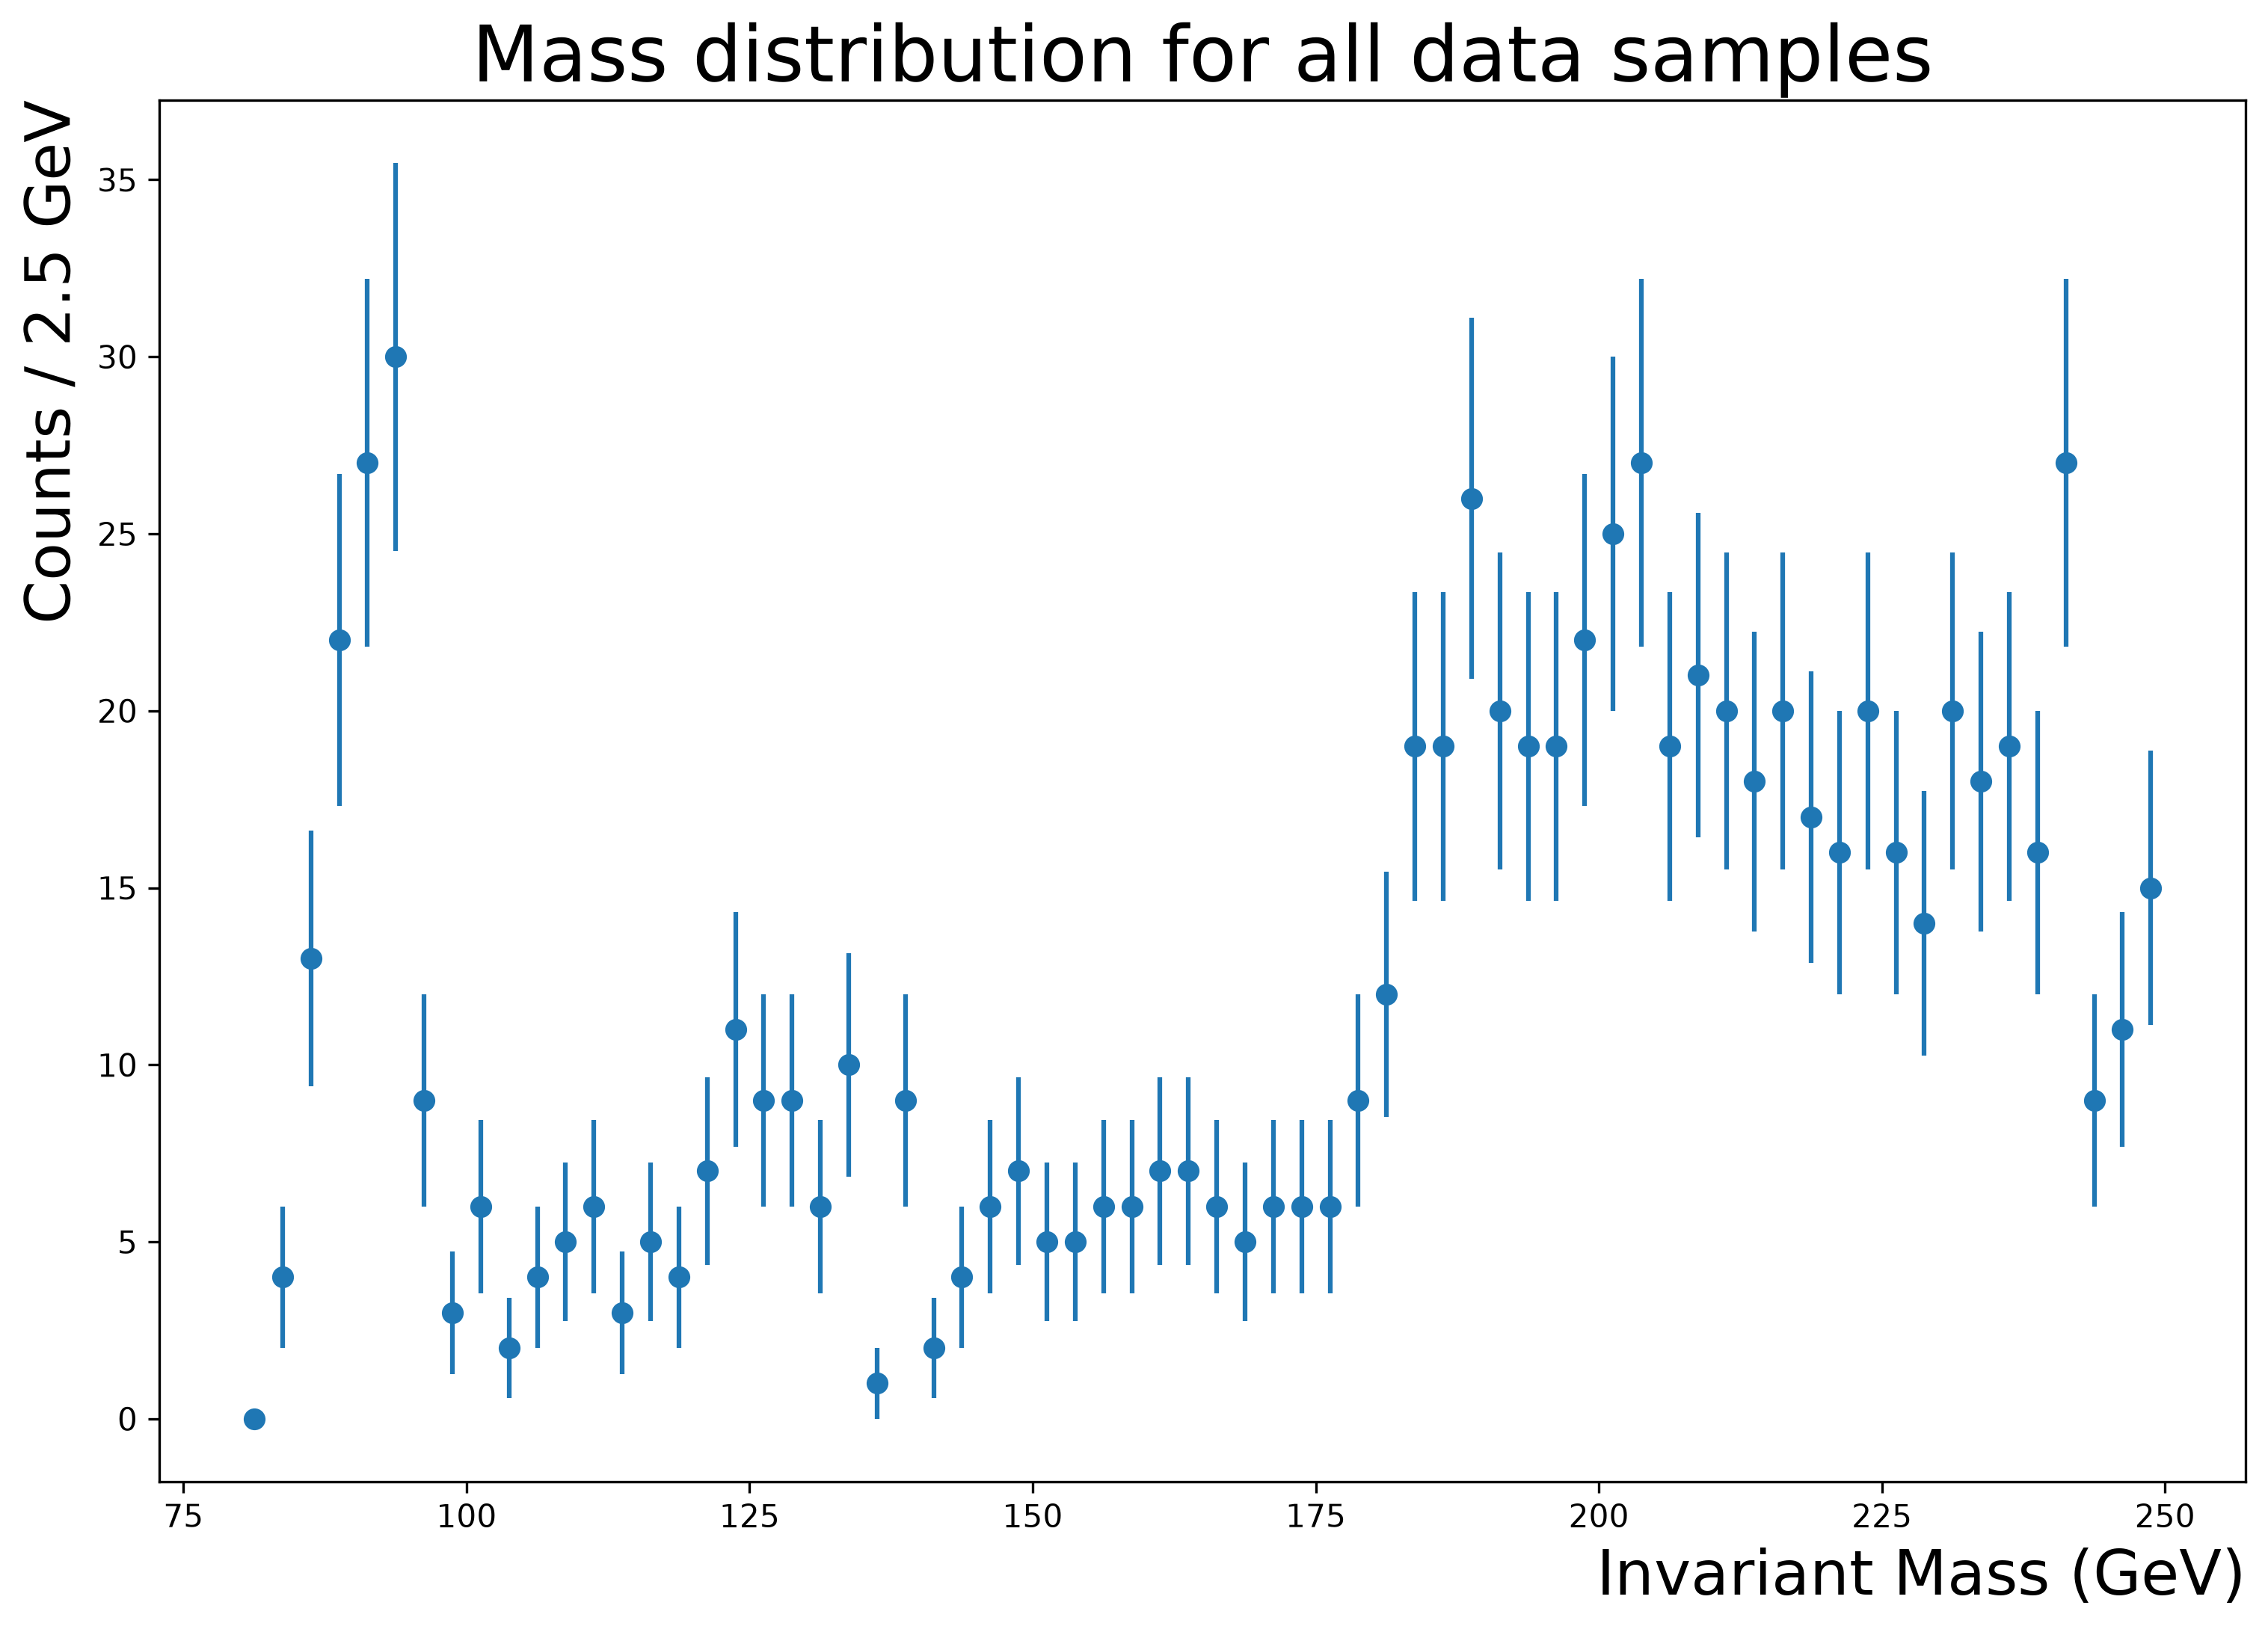

In [86]:
# Make plots -> start with just data

# plot variables
#TODO - change the plot dynamics
xmin = 80 # GeV for all 
xmax = 250
stepsize = 2.5 
binlist = np.arange(xmin,xmax+stepsize,stepsize)
bincenters = np.arange(xmin+stepsize/2,xmax+stepsize/2,stepsize)


data_x = ak.to_numpy(allmass['Data'])
print(f'Num of data events that pass cut: {len(data_x)}')
data_y,_ = np.histogram(data_x,bins=binlist)
data_y_err = np.sqrt(data_y) # statistical error use poisson uncertainty

print(len(bincenters),len(data_y))

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o')

ax.set_xlabel("Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title("Mass distribution for all data samples",fontsize=25)



Text(100, 60, '$\\sqrt{s}$ = 13 TeV, $\\int L dt =$ 36.6fb$^{-1}$')

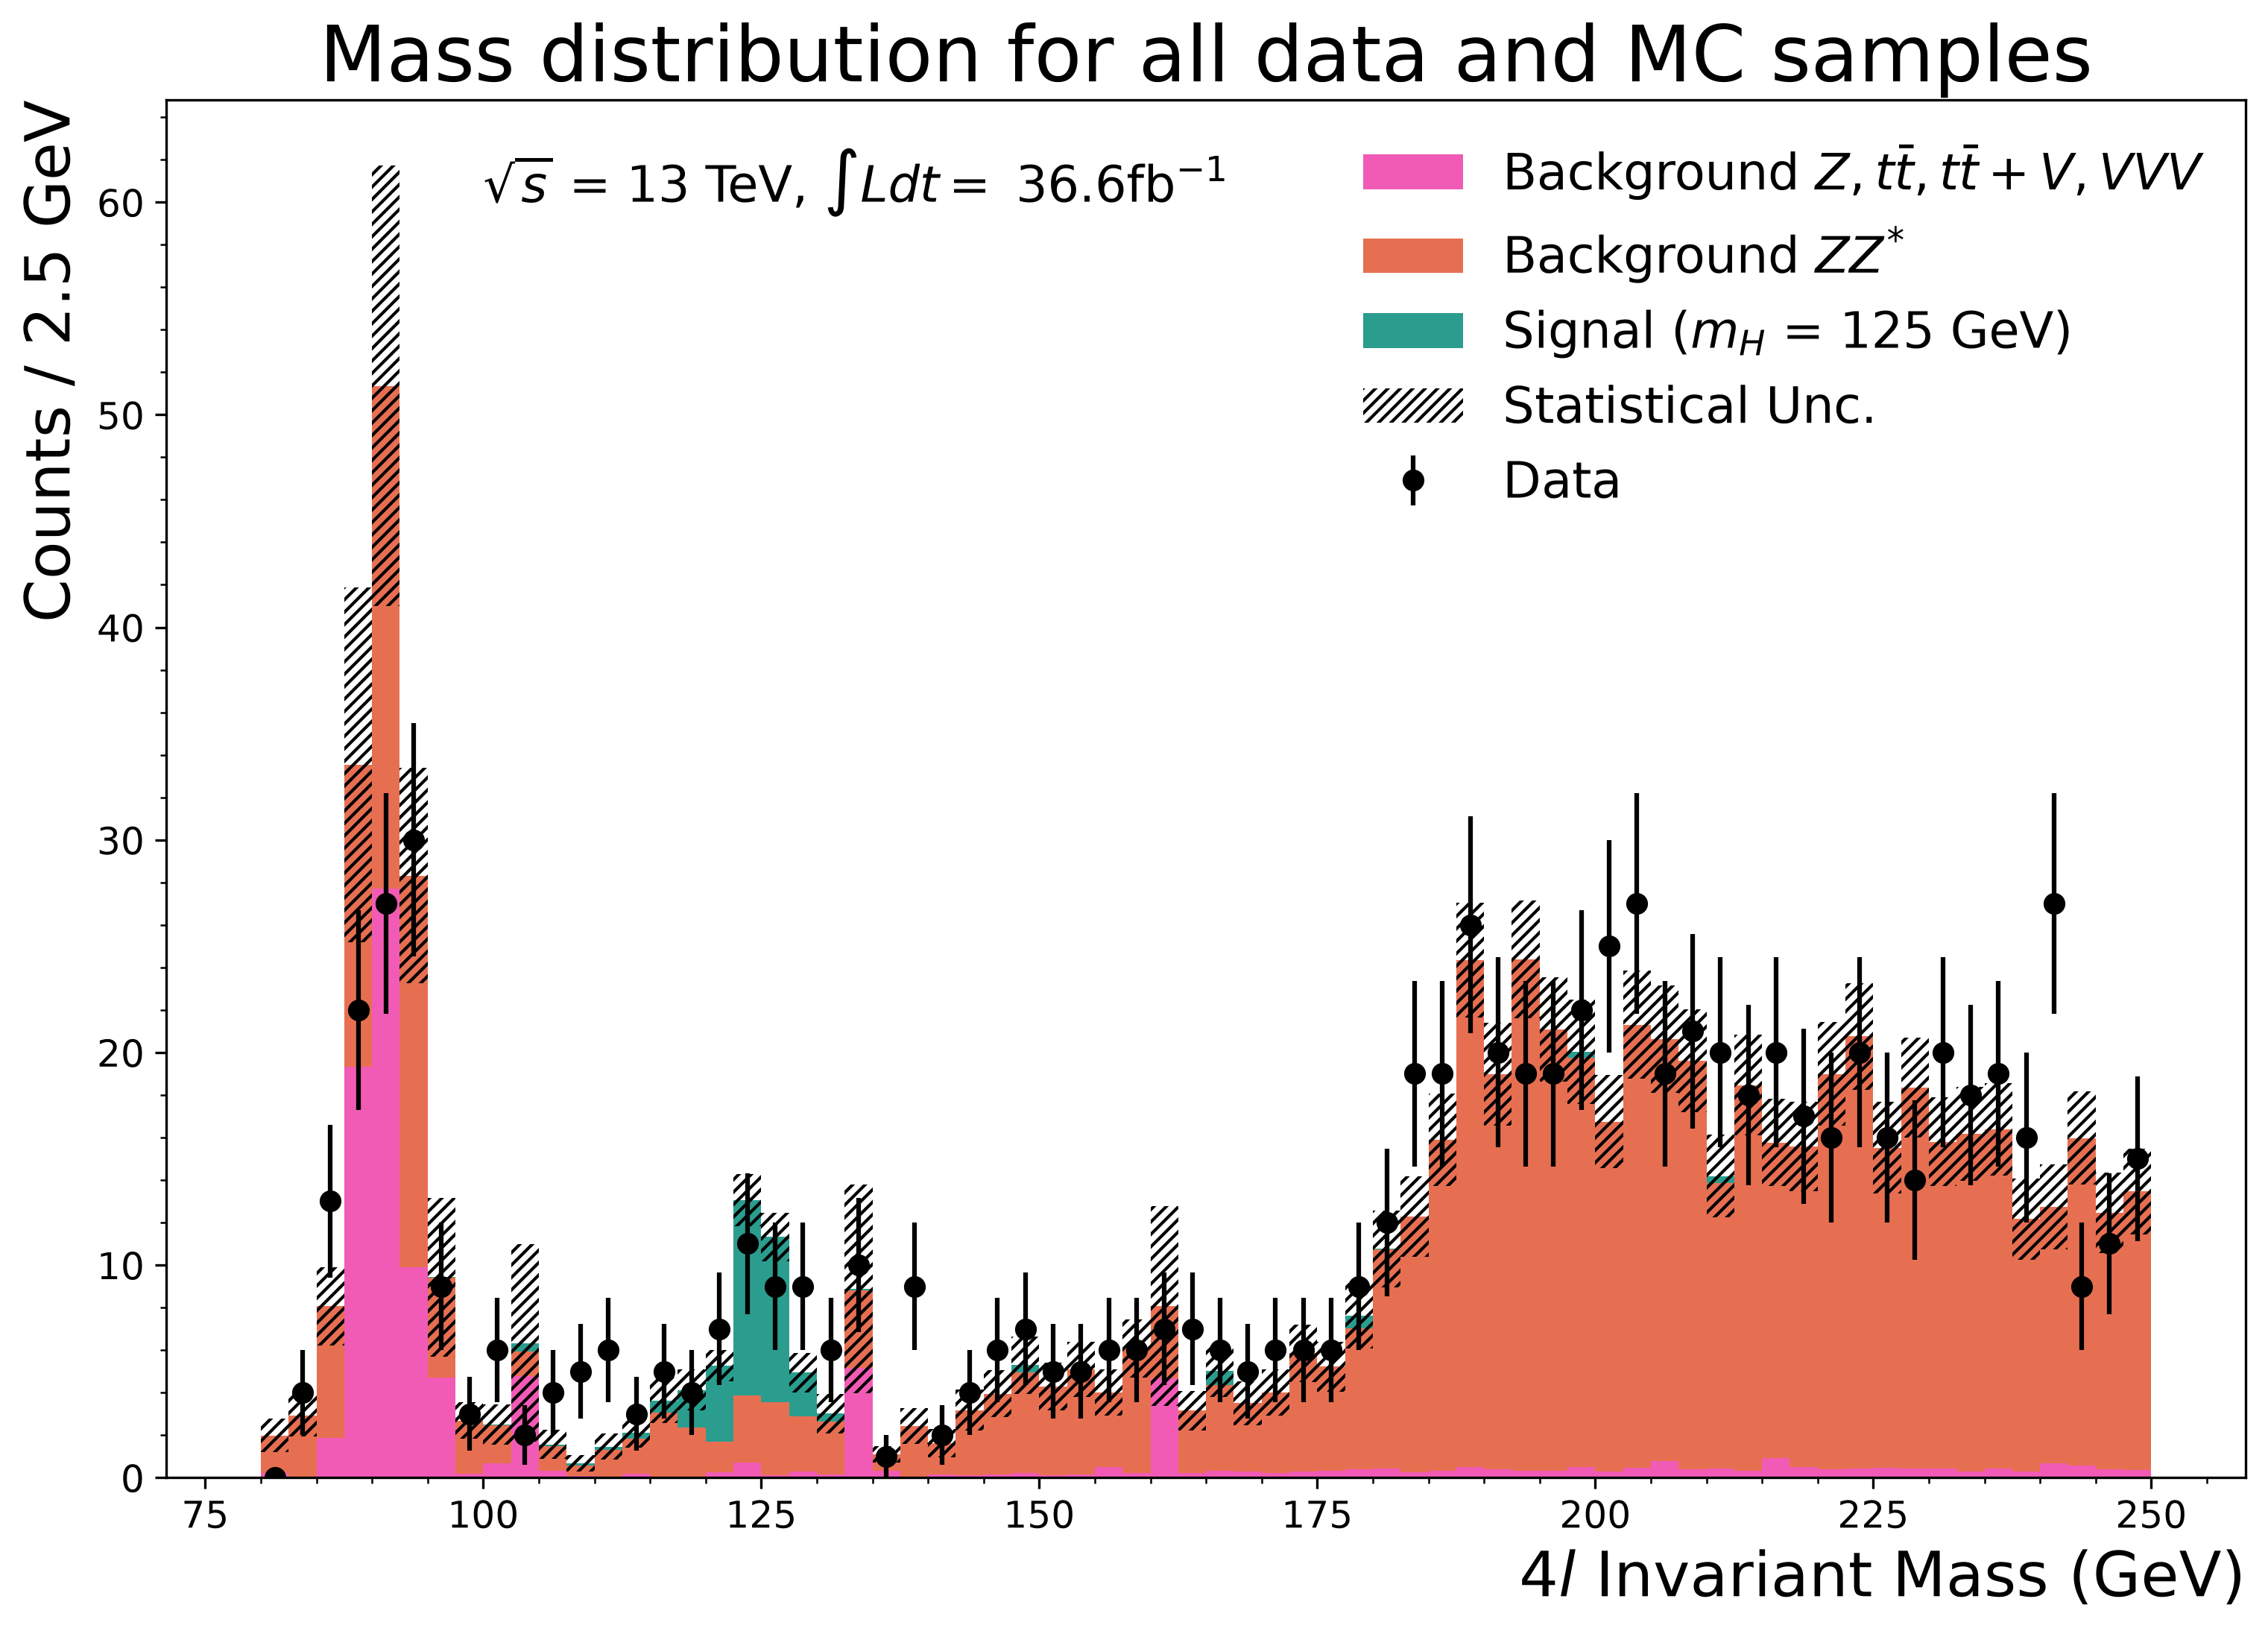

In [176]:
# Now make plots with data and MC

# don't need to histogram the MC data because we are plotting them as hist, use plt.hist

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
# make lists for the different MC samples for each of the attributes needed for plotting
mc_masses = [] # each entry will be a list of the masses for that MC sample
mc_weights = []
mc_labels = []
#TODO - rescue these colors
#mc_colors = ['#6CBAA9','#E4A199','#E8A87C'] # pastel
#mc_colors = ['#4A274E','#E4A199','#D3C5E5']
mc_colors = ['#A8DADC', '#457B9D', '#1D3557'] # blue pastel
mc_colors = ['#E9C46A', '#F4A261', '#E76F51']
mc_colors = ['#FF9F1C', '#2EC4B6', '#118AB2']
mc_colors = ['#FFB703', '#FF4D80', '#023047']
mc_colors = ['#F15BB5', '#E76F51', '#2A9D8F']
for s in allsamples:
    if s != 'Data': # just MC samples
        # make numpy lists of the mass+weights
        thismc_mass = ak.to_numpy(allinfo[s]['mass'])
        mc_masses.append(thismc_mass)
        thismc_weights = ak.to_numpy(allinfo[s]['totalWeight'])
        mc_weights.append(thismc_weights)
        #mc_colors.append(allsamples[s]['color'])
        mc_labels.append(s)

mc_hist = ax.hist(mc_masses,bins=binlist,weights=mc_weights,
        label=mc_labels,color=mc_colors,stacked=True)

# this mc_hist object is a tuple, first entry is a 2D array for the height of the hist
# the first entry is the heights of bins for first sample
# if stacked=True, second entry is heights of first + second
# third entry is height of first+second+third, etc.
# so take the last row of the first element of the mc_hist tuple to get cumulative height
mc_height_sum = mc_hist[0][-1]


# now make error bars for the MC samples
# in the tutorial files they only do error bars for the MC BG, i include signal
# concatenate all mc weights and mass into long list
mc_weights_all = np.concatenate(mc_weights)
mc_masses_all = np.concatenate(mc_masses)
# the total variance per bin is the weight^2
# so histogram the masses with weight^2
mc_var_hist = np.histogram(mc_masses_all,bins=binlist, weights=mc_weights_all**2)
# np hist returns tuple, first element is bin height
mc_err = np.sqrt(mc_var_hist[0])

# plot mc errorbars
# calc the bottom of the bar with the height of the total mc
ax.bar(bincenters,height=mc_err*2,bottom=(mc_height_sum-mc_err),
       hatch='//////',color='none',alpha=0.5,width=stepsize,label="Statistical Unc.")


#TODO - find better text for labeling plot
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o',color='black',label='Data') 

#TODO - explain plot, think about discrepencies between data and MC bg predictions
#TODO - also think about the luminosity

ax.set_xlabel(r"$4l$ Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title("Mass distribution for all data and MC samples",fontsize=25)
ax.legend(frameon=False,fontsize=16)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.text(100,60,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)